# MNIST Active Learning Project

## Setup and Imports

In [1]:
pip install label-studio-sdk

In [2]:
import torch
import base64, time, io
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, pairwise_distances
from PIL import Image
from label_studio_sdk import LabelStudio
from google.colab import userdata

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# 1. Data Loading and Preprocessing

In [3]:
train_set = MNIST('./data', train=True, download=True)
test_set = MNIST('./data', train=False, download=True)

X_train = train_set.data.numpy().reshape(-1, 28*28) / 255.0
y_train = train_set.targets.numpy()

X_test = test_set.data.numpy().reshape(-1, 28*28) / 255.0
y_test = test_set.targets.numpy()

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 512kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]


Train shape: (60000, 784)
Test shape: (10000, 784)


# 2. Baseline Model (Random Forest)

In [4]:
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

y_pred = rf_baseline.predict(X_test)
print("--- Classification Report (Baseline) ---")
print(classification_report(y_test, y_pred))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")

--- Classification Report (Baseline) ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

Overall Accuracy: 0.9704


# 3. Active Learning Strategy Components

In [5]:
def get_uncertainty_samples(model: RandomForestClassifier,
                            X_pool: np.ndarray,
                            n_instances: int = 10) -> np.ndarray:
    probs = model.predict_proba(X_pool)

    max_probs = np.max(probs, axis=1)

    uncertain_indices = np.argsort(max_probs)[:n_instances]
    return uncertain_indices

In [6]:
def get_diversity_samples(X_labeled: np.ndarray,
                          X_pool: np.ndarray,
                          n_instances: int = 10,
                          dev: torch.device = device) -> np.ndarray:

    X_pool_t = torch.tensor(X_pool, dtype=torch.float32).to(dev)
    X_labeled_t = torch.tensor(X_labeled, dtype=torch.float32).to(dev)

    distances_t = torch.cdist(X_pool_t, X_labeled_t, p=2)

    min_distances_t = torch.min(distances_t, dim=1)[0]
    min_distances = min_distances_t.cpu().numpy()

    diverse_indices = np.argsort(min_distances)[-n_instances:]

    return diverse_indices

In [7]:
def get_combined_samples(model: RandomForestClassifier,
                         X_labeled: np.ndarray,
                         X_pool: np.ndarray,
                         n_instances: int = 10) -> np.ndarray:
  uncertain_candidates_idx = get_uncertainty_samples(model=model, X_pool=X_pool, n_instances=n_instances)

  X_candidates = X_pool[uncertain_candidates_idx]

  diverse_sub_idx = get_diversity_samples(X_labeled=X_labeled, X_pool=X_candidates, n_instances=n_instances)
  return uncertain_candidates_idx[diverse_sub_idx]

# 4.Label Studio Integration


In [8]:
LABEL_STUDIO_URL = 'https://guy-watch-smoked.ngrok-free.dev'
LABEL_STUDIO_API_KEY = userdata.get('LABEL_STUDIO_KEY')

client = LabelStudio(base_url=LABEL_STUDIO_URL, api_key=LABEL_STUDIO_API_KEY)
me = client.users.whoami()
print(f"Connected as: {me.username} ({me.email})")

Connected as: di251506 (di251506@ustp-students.at)


In [9]:
LABEL_CONFIG = """
<View>
  <Image name="image" value="$image"/>
  <Choices name="digit" toName="image" choice="single">
    <Choice value="0"/><Choice value="1"/><Choice value="2"/>
    <Choice value="3"/><Choice value="4"/><Choice value="5"/>
    <Choice value="6"/><Choice value="7"/><Choice value="8"/>
    <Choice value="9"/>
  </Choices>
</View>
"""

project = client.projects.create(
    title="MNIST Active Learning",
    label_config=LABEL_CONFIG,
)
print(f"Project created: ID={project.id}")

Project created: ID=2


In [10]:
def array_to_base64(x_flat: np.ndarray) -> str:
    img_array = (x_flat.reshape(28, 28) * 255).astype(np.uint8)
    img = Image.fromarray(img_array)
    buf = io.BytesIO()
    img.save(buf, format='PNG')
    b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    return f"data:image/png;base64,{b64}"

In [11]:
N_SEED = 100
N_QUERY = 20

labeled_indices = np.random.choice(len(X_train), N_SEED, replace=False)
pool_indices = np.setdiff1d(np.arange(len(X_train)), labeled_indices)

X_labeled = X_train[labeled_indices]
y_labeled = y_train[labeled_indices]
X_pool = X_train[pool_indices]

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_labeled, y_labeled)

sampled_sub_idx = get_combined_samples(
    model=model,
    X_labeled=X_labeled,
    X_pool=X_pool,
    n_instances=N_QUERY
)
sampled_pool_idx = pool_indices[sampled_sub_idx]
X_to_annotate = X_train[sampled_pool_idx]

tasks_data = []
for i, x in enumerate(X_to_annotate):
    tasks_data.append({
        "image": array_to_base64(x),
        "original_index": int(sampled_pool_idx[i])
    })

resp = client.projects.import_tasks(
    id=project.id,
    request=tasks_data,
    return_task_ids=True,
)
print(f"{len(tasks_data)} tasks sent.")
print(f"→ Open {LABEL_STUDIO_URL}/projects/{project.id}/ and label the images.")

20 tasks sent.
→ Open https://guy-watch-smoked.ngrok-free.dev/projects/2/ and label the images.


In [12]:
def wait_for_annotations(client: LabelStudio,
                         project_id: int,
                         expected_count: int,
                         poll_interval: int = 10) -> None:
    print("Waiting for annotations...")
    while True:
        tasks = list(client.tasks.list(project=project_id))
        annotated = sum(1 for t in tasks if getattr(t, 'total_annotations', 0) > 0)
        print(f"\r  Annotated: {annotated}/{expected_count}", end="", flush=True)

        if annotated >= expected_count:
            print(" \u2713")
            return
        time.sleep(poll_interval)

wait_for_annotations(client, project.id, expected_count=N_QUERY)

Waiting for annotations...
  Annotated: 20/20 ✓


In [13]:
tasks_done = list(client.tasks.list(project=project.id))

new_X, new_y = [], []
for task in tasks_done:
    if not task.total_annotations:
        continue

    annotations = list(client.annotations.list(id=task.id))
    if not annotations:
        continue

    label_str = annotations[0].result[0]["value"]["choices"][0]
    label_int = int(label_str)

    orig_idx = task.data["original_index"]
    new_X.append(X_train[orig_idx])
    new_y.append(label_int)

new_X = np.array(new_X)
new_y = np.array(new_y)

print(f"Retrieved: {len(new_X)} annotated samples")
print(f"Label distribution: {dict(zip(*np.unique(new_y, return_counts=True)))}")

Retrieved: 20 annotated samples
Label distribution: {np.int64(0): np.int64(2), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(1), np.int64(5): np.int64(7), np.int64(6): np.int64(2), np.int64(8): np.int64(5)}


In [14]:
X_labeled = np.vstack([X_labeled, new_X])
y_labeled  = np.concatenate([y_labeled, new_y])

print(f"New training set: {len(X_labeled)} samples "
      f"(was: {N_SEED}, new: {len(new_X)})")

New training set: 120 samples (was: 100, new: 20)


## Comparative Active Learning Loop

In [15]:
# Uncertainty Sampling Variant 1: Least Confidence
def get_uncertainty_samples_least_confidence(model: RandomForestClassifier,
                                             X_pool: np.ndarray,
                                             n_instances: int = 10) -> np.ndarray:
    probs = model.predict_proba(X_pool)
    max_probs = np.max(probs, axis=1)
    return np.argsort(max_probs)[:n_instances]

# Uncertainty Sampling Variant 2: Entropy Sampling
def get_uncertainty_samples_entropy(model: RandomForestClassifier,
                                    X_pool: np.ndarray,
                                    n_instances: int = 10) -> np.ndarray:
    probs = model.predict_proba(X_pool)
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    return np.argsort(entropy)[-n_instances:]

def retrain_model(X_labeled: np.ndarray, y_labeled: np.ndarray) -> RandomForestClassifier:
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_labeled, y_labeled)
    return model

def evaluate_model(model: RandomForestClassifier,
                   X_test: np.ndarray,
                   y_test: np.ndarray,
                   label: str = "") -> float:
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"  Accuracy {label}: {acc:.4f}")
    return acc

In [16]:
labeled_idx_set = set(labeled_indices.tolist()) | set(sampled_pool_idx.tolist())
all_indices = np.arange(len(X_train))
pool_indices_clean = np.array([i for i in all_indices if i not in labeled_idx_set])

X_lab_base = X_train[list(labeled_idx_set)]
y_lab_base = y_train[list(labeled_idx_set)]

X_lab_unc, y_lab_unc = X_lab_base.copy(), y_lab_base.copy()
X_lab_ent, y_lab_ent = X_lab_base.copy(), y_lab_base.copy()
X_lab_div, y_lab_div = X_lab_base.copy(), y_lab_base.copy()

pool_idx_unc = pool_indices_clean.copy()
pool_idx_ent = pool_indices_clean.copy()
pool_idx_div = pool_indices_clean.copy()

print(f"Labeled Start: {len(X_lab_base)} Samples")
print(f"Pool Start:    {len(pool_indices_clean)} Samples")

Labeled Start: 120 Samples
Pool Start:    59880 Samples


In [17]:
N_ITERATIONS = 10
N_QUERY = 200

results_least_conf = []
results_entropy = []
results_diversity = []
results_combined = []
results_random = []

# Copies for each strategy (same starting point)
X_lab_unc, y_lab_unc = X_lab_base.copy(), y_lab_base.copy()
X_lab_ent, y_lab_ent = X_lab_base.copy(), y_lab_base.copy()
X_lab_div, y_lab_div = X_lab_base.copy(), y_lab_base.copy()
X_lab_com, y_lab_com = X_lab_base.copy(), y_lab_base.copy()
X_lab_rnd, y_lab_rnd = X_lab_base.copy(), y_lab_base.copy()

pool_idx_unc = pool_indices_clean.copy()
pool_idx_ent = pool_indices_clean.copy()
pool_idx_div = pool_indices_clean.copy()
pool_idx_com = pool_indices_clean.copy()
pool_idx_rnd = pool_indices_clean.copy()

print("=" * 65)
print(f"Start: {len(X_lab_base)} labeled | Pool: {len(pool_indices_clean)}")
print("=" * 65)

for iteration in range(1, N_ITERATIONS + 1):
    print(f"\n-- Iteration {iteration}/{N_ITERATIONS} " + "-" * 30)

    # 1. Least Confidence
    model_unc = retrain_model(X_lab_unc, y_lab_unc)
    idx_sub = get_uncertainty_samples_least_confidence(model_unc, X_train[pool_idx_unc], N_QUERY)
    picked = pool_idx_unc[idx_sub]
    X_lab_unc = np.vstack([X_lab_unc, X_train[picked]])
    y_lab_unc = np.concatenate([y_lab_unc, y_train[picked]])
    pool_idx_unc = np.setdiff1d(pool_idx_unc, picked)
    acc = evaluate_model(retrain_model(X_lab_unc, y_lab_unc), X_test, y_test, f"Least Confidence (n={len(X_lab_unc)})")
    results_least_conf.append((len(X_lab_unc), acc))

    # 2. Entropy Sampling
    model_ent = retrain_model(X_lab_ent, y_lab_ent)
    idx_sub = get_uncertainty_samples_entropy(model_ent, X_train[pool_idx_ent], N_QUERY)
    picked = pool_idx_ent[idx_sub]
    X_lab_ent = np.vstack([X_lab_ent, X_train[picked]])
    y_lab_ent = np.concatenate([y_lab_ent, y_train[picked]])
    pool_idx_ent = np.setdiff1d(pool_idx_ent, picked)
    acc = evaluate_model(retrain_model(X_lab_ent, y_lab_ent), X_test, y_test, f"Entropy (n={len(X_lab_ent)})")
    results_entropy.append((len(X_lab_ent), acc))

    # 3. Diversity Sampling
    model_div = retrain_model(X_lab_div, y_lab_div)
    idx_sub = get_diversity_samples(X_lab_div, X_train[pool_idx_div], N_QUERY)
    picked = pool_idx_div[idx_sub]
    X_lab_div = np.vstack([X_lab_div, X_train[picked]])
    y_lab_div = np.concatenate([y_lab_div, y_train[picked]])
    pool_idx_div = np.setdiff1d(pool_idx_div, picked)
    acc = evaluate_model(retrain_model(X_lab_div, y_lab_div), X_test, y_test, f"Diversity (n={len(X_lab_div)})")
    results_diversity.append((len(X_lab_div), acc))

    # 4. Combined Sampling
    model_com = retrain_model(X_lab_com, y_lab_com)
    idx_sub = get_combined_samples(model_com, X_lab_com, X_train[pool_idx_com], N_QUERY)
    picked = pool_idx_com[idx_sub]
    X_lab_com = np.vstack([X_lab_com, X_train[picked]])
    y_lab_com = np.concatenate([y_lab_com, y_train[picked]])
    pool_idx_com = np.setdiff1d(pool_idx_com, picked)
    acc = evaluate_model(retrain_model(X_lab_com, y_lab_com), X_test, y_test, f"Combined (n={len(X_lab_com)})")
    results_combined.append((len(X_lab_com), acc))

    # 5. Random Sampling
    idx_sub = np.random.choice(len(pool_idx_rnd), N_QUERY, replace=False)
    picked = pool_idx_rnd[idx_sub]
    X_lab_rnd = np.vstack([X_lab_rnd, X_train[picked]])
    y_lab_rnd = np.concatenate([y_lab_rnd, y_train[picked]])
    pool_idx_rnd = np.setdiff1d(pool_idx_rnd, picked)
    acc = evaluate_model(retrain_model(X_lab_rnd, y_lab_rnd), X_test, y_test, f"Random (n={len(X_lab_rnd)})")
    results_random.append((len(X_lab_rnd), acc))

print("\n Finished.")

Start: 120 labeled | Pool: 59880

-- Iteration 1/10 ------------------------------
  Accuracy Least Confidence (n=320): 0.7669
  Accuracy Entropy (n=320): 0.7465
  Accuracy Diversity (n=320): 0.8088
  Accuracy Combined (n=320): 0.7629
  Accuracy Random (n=320): 0.8340

-- Iteration 2/10 ------------------------------
  Accuracy Least Confidence (n=520): 0.8283
  Accuracy Entropy (n=520): 0.8457
  Accuracy Diversity (n=520): 0.7908
  Accuracy Combined (n=520): 0.8308
  Accuracy Random (n=520): 0.8784

-- Iteration 3/10 ------------------------------
  Accuracy Least Confidence (n=720): 0.8629
  Accuracy Entropy (n=720): 0.8584
  Accuracy Diversity (n=720): 0.7882
  Accuracy Combined (n=720): 0.8673
  Accuracy Random (n=720): 0.8915

-- Iteration 4/10 ------------------------------
  Accuracy Least Confidence (n=920): 0.8853
  Accuracy Entropy (n=920): 0.8566
  Accuracy Diversity (n=920): 0.7918
  Accuracy Combined (n=920): 0.8906
  Accuracy Random (n=920): 0.8989

-- Iteration 5/10 ----

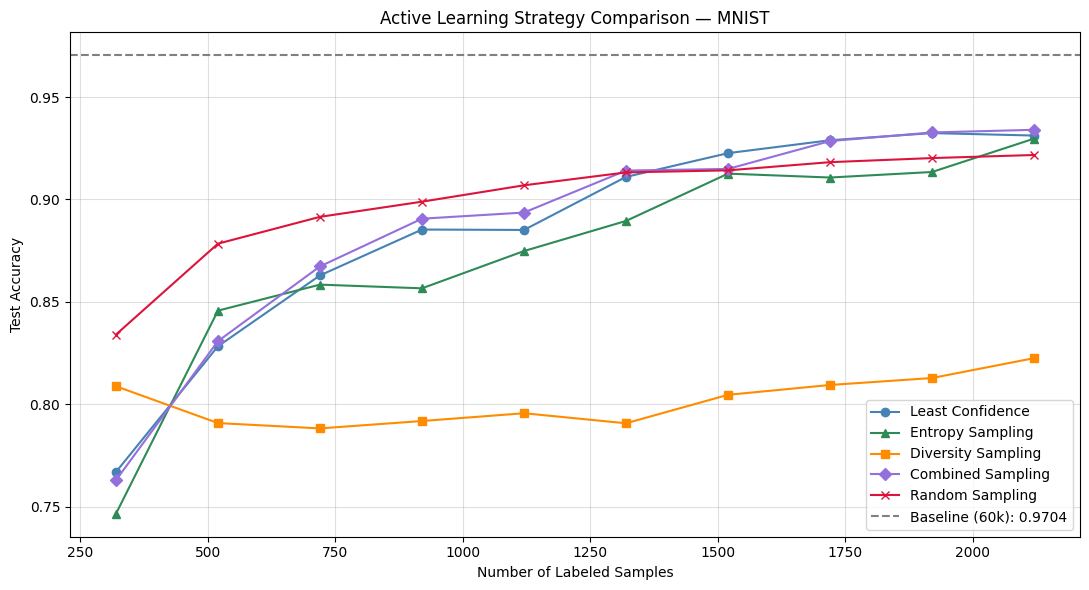


n       Least C.   Entropy    Diversity   Combined    Random
--------------------------------------------------------------
320     0.7669    0.7465    0.8088     0.7629     0.8340
520     0.8283    0.8457    0.7908     0.8308     0.8784
720     0.8629    0.8584    0.7882     0.8673     0.8915
920     0.8853    0.8566    0.7918     0.8906     0.8989
1120    0.8851    0.8748    0.7956     0.8936     0.9069
1320    0.9110    0.8895    0.7907     0.9141     0.9132
1520    0.9226    0.9126    0.8046     0.9149     0.9142
1720    0.9289    0.9107    0.8094     0.9285     0.9182
1920    0.9324    0.9134    0.8128     0.9327     0.9202
2120    0.9312    0.9297    0.8225     0.9340     0.9217

Baseline (60,000 Samples): 0.9704


In [18]:
baseline_acc = accuracy_score(y_test, rf_baseline.predict(X_test))

fig, ax = plt.subplots(figsize=(11, 6))

for results, label, color, marker in [
    (results_least_conf, 'Least Confidence',  'steelblue',   'o'),
    (results_entropy,    'Entropy Sampling',  'seagreen',    '^'),
    (results_diversity,  'Diversity Sampling','darkorange',  's'),
    (results_combined,   'Combined Sampling', 'mediumpurple','D'),
    (results_random,     'Random Sampling',   'crimson',     'x'),
]:
    sizes, accs = zip(*results)
    ax.plot(sizes, accs, marker=marker, label=label, color=color)

ax.axhline(baseline_acc, color='gray', linestyle='--',
           label=f'Baseline (60k): {baseline_acc:.4f}')

ax.set_xlabel('Number of Labeled Samples')
ax.set_ylabel('Test Accuracy')
ax.set_title('Active Learning Strategy Comparison — MNIST')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# -- Table --
print(f"\n{'n':<7} {'Least C.':<10} {'Entropy':<10} {'Diversity':<11} {'Combined':<11} {'Random'}")
print('-' * 62)
for lc, ent, div, com, rnd in zip(
        results_least_conf, results_entropy,
        results_diversity, results_combined, results_random):
    print(f"{lc[0]:<7} {lc[1]:.4f}    {ent[1]:.4f}    {div[1]:.4f}     {com[1]:.4f}     {rnd[1]:.4f}")
print(f"\nBaseline (60,000 Samples): {baseline_acc:.4f}")

## Results Analysis